### Detect spots with TrackPy and save CSVs ready for MakeCropArrays.ipynb.

In [2]:
import croparray as ca
from pathlib import Path

In [8]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

DATA_DIR   = Path(r"Z:\SharedInternal\RiboJamProject\20260508_deltaZNF_LightInducedJams\WT_U2OS")
VID_FILES  = sorted(DATA_DIR.glob("*.tif"))

DETECT_CH   = 2     # Channel index (0-based) to use for spot detection
DIAMETER    = 7     # Estimated spot diameter in pixels (must be odd)
FRAME_INDEX = None  # Frame for preview/threshold review; None = middle frame
MAX_SPOTS   = 200   # Safety cap: auto-threshold will never exceed this many spots/frame

TRACK          = True  # Link spots into tracks?
SEARCH_RANGE   = 5     # Max displacement (pixels) between frames
MEMORY         = 2     # Frames a spot can vanish and still be linked
MIN_TRACK_LEN  = 3     # Drop tracks shorter than this (frames)

SPOTS_SUFFIX = "_spots"   # Output: <video_stem>_spots.csv  (all detections)
TRACKS_SUFFIX = "_tracks" # Output: <video_stem>_tracks.csv (linked tracks, if TRACK=True)
OUT_DIR      = DATA_DIR   # Where to save CSVs

Auto-detected minmass: 3916.1  |  Using: 3916.1


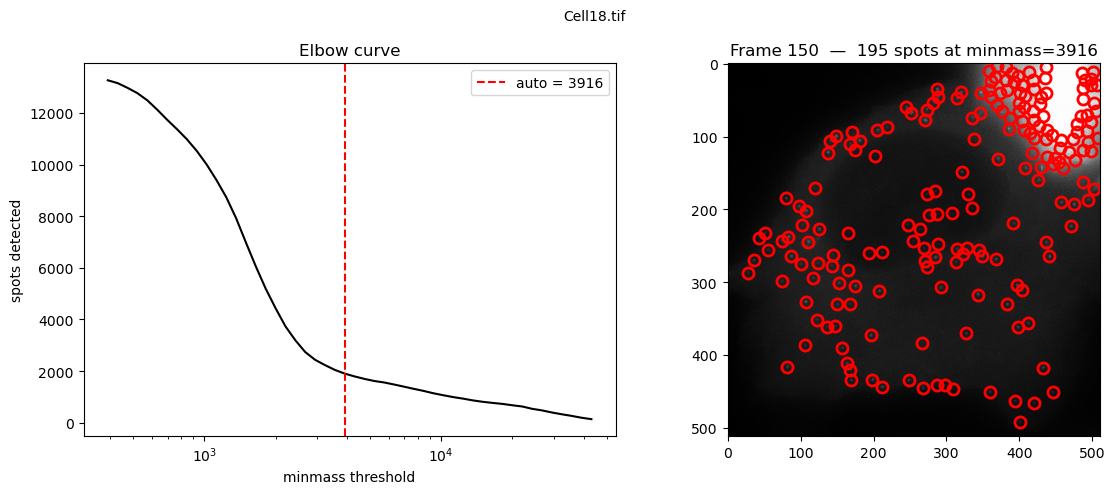

In [9]:
# Preview a single video to check DIAMETER. Axis-labeling GUI will open first.
ca.build.preview_detection(VID_FILES[0], detect_ch=DETECT_CH,
                            diameter=DIAMETER, frame_index=FRAME_INDEX,
                            max_spots=MAX_SPOTS)

In [10]:
# (Optional) Draw polygon ROIs to exclude spots outside regions of interest.
# Opens napari showing max(t,z) projection for each video — scroll through frames,
# draw one polygon per frame using the Polygon tool (P), then close the window.
# Saves <video_stem>__roi.json sidecars; make_csvs applies them automatically.
rois = ca.build.review_rois(VID_FILES, detect_ch=DETECT_CH)

Computing max projections for ROI review...
  Cell18.tif: (512, 512)
  Cell19.tif: (512, 512)
  Cell24.tif: (512, 512)
  Cell25.tif: (512, 512)
  Cell35.tif: (512, 512)
  Cell38.tif: (512, 512)
  Cell39.tif: (512, 512)
  Cell40.tif: (512, 512)
  Cell41.tif: (512, 512)

Instructions:
  Scroll the bottom slider — each frame = one video:
    frame   0:  Cell18.tif
    frame   1:  Cell19.tif
    frame   2:  Cell24.tif
    frame   3:  Cell25.tif
    frame   4:  Cell35.tif
    frame   5:  Cell38.tif
    frame   6:  Cell39.tif
    frame   7:  Cell40.tif
    frame   8:  Cell41.tif
  Select the Polygon tool (P) and draw one ROI per frame.
  Click 'Save ROIs' in the right panel when done.


In [ ]:
# Review and adjust per-video thresholds.
# Use the dropdown to switch videos, slider to adjust minmass.
# Changes are saved automatically — just run the next cell when done.
thresholds = ca.build.review_thresholds(VID_FILES, detect_ch=DETECT_CH,
                                         diameter=DIAMETER, frame_index=FRAME_INDEX,
                                         max_spots=MAX_SPOTS)

In [ ]:
# Batch detect + track all videos using the reviewed thresholds, then save CSVs.
# Always saves: <stem>_spots.csv  (all detections)
# If TRACK=True: <stem>_tracks.csv (linked + filtered tracks)
ca.build.make_csvs(VID_FILES, detect_ch=DETECT_CH, diameter=DIAMETER,
                   minmass=thresholds, track=TRACK, search_range=SEARCH_RANGE,
                   memory=MEMORY, min_track_len=MIN_TRACK_LEN,
                   spots_suffix=SPOTS_SUFFIX, tracks_suffix=TRACKS_SUFFIX,
                   out_dir=OUT_DIR)